# Visualizing networks with `pathpyG`

*August 4 2026*  
*Training Workshop: Introduction to Deep Graph Learning*  
*Ingo Scholtes, CAIDAS, Julius-Maximilians-Universität Würzburg (JMU), Germany*  

A key feature of `pathpyG` is its support for custumizable interactive visualisations that can be embedded in jupyter notebooks or stored as stand-alone files. In the following, we show this functionality in some toy examples before moving to real data sets in the next unit. We first import `pathpyG` as usual. 

In [1]:
import pathpyG as pp

## Loading Networks

Before we can visualize a network, we first need to get some network data into `pathpyG`. In practice, network data usually comes from one of two sources: a local file (e.g. a CSV file containing an edge list) or an online repository that hosts empirical network data sets. In the following, we briefly introduce both ways of loading networks, before we move on to the actual topic of this notebook: visualizing networks.

### Loading networks from files

`pathpyG` provides the function `pp.io.read_csv_graph()` to read a static graph from a CSV file that contains one edge per line. By default, the file is expected to have a header row with columns `v` and `w`, which contain the source and target node of each edge (additional columns are read as edge attributes). Conversely, we can use `pp.io.write_csv()` to write a `Graph` object to a CSV file. Let's try this by creating a small example graph, writing it to a file, and reading it back in:

In [ ]:
g_file = pp.Graph.from_edge_list([('a', 'b'), ('b', 'c'), ('c', 'a')])

pp.io.write_csv(g_file, path_or_buf='data/test_graph.csv')

g_from_file = pp.io.read_csv_graph('data/test_graph.csv')
print(g_from_file)

### Loading networks from the netzschleuder repository

For real (empirical) network data sets, it is often more convenient to directly load data from an online repository rather than manually downloading and parsing files. [Netzschleuder](https://networks.skewed.de/) is a large, public repository of network data sets. In the `pathpyG.io` module, there is a function that allows us to directly read graph data from the netzschleuder API.

We can read a given network from the netzschleuder database using its record name. Just browse the [Netzschleuder Online Repository to find the record names](https://networks.skewed.de/). As an example, we use a graph capturing co-purchase relationships between political books.

In [ ]:
g = pp.io.read_netzschleuder_graph(name='polbooks')
g.mapping = pp.IndexMap(g.data.node_label)
print(g)

In [ ]:
pp.plot(g);

We can also read the famous karate club network. The record karate actually contains two networks with labels 77 and 78, which refer to two different versions of the data with different numbers of edges. If multiple graph data sets exist in the same record, we can specify the name of the network as second argument.

In [ ]:
g = pp.io.read_netzschleuder_graph(name='karate', network='78')
print(g);

We see that the nodes actually have a node_groups property, which maps the nodes to two groups. Those groups are often used as ground truth for communities in this simple illustrative graph. We will instead use it as ground truth categorical node label for a node classification experiment based on a Graph Neural Network.

Conveniently, numerical node attributes (either scalar or vector values) are automatically converted to torch tensors, so we can directly use them for a GNN.

In [ ]:
print(g.data.node_groups)

For convenience, let us shift the group labels to binary values 0 and 1:

In [ ]:
g.data.node_groups -= 1
print(g.data.node_groups)

In [ ]:
pp.plot(g, node_color=[g["node_groups", v].item() for v in g.nodes])

We first create a simple toy example by adding two edges between three nodes.

In [3]:
n = pp.Graph.from_edge_list([('a', 'b'), ('b', 'c')])
print(n)

Directed graph with 3 nodes and 2 edges
{'Edge Attributes': {}, 'Graph Attributes': {'num_nodes': "<class 'int'>"}, 'Node Attributes': {}}


Calling the `print` function on a network instance will generate a string representation that can be printed on the console. The simplest way to graphically visualise the network in a jupyter notebook is to call the `pp.plot` function on the network. This will create an interactive HTML visualisation of the network, where we can zoom, pan, and drag nodes (press Shift while panning, clicking, or using the mouse wheel). Try to zoom and pan the network (by holding the shift key and using the mouse/mouse wheel). Try what happens if you drag a node and release the mouse button.

In [5]:
pp.plot(n);

By default a default style is applied to the network but pathpy allows to fully style the network based on a custom style dictionary that can be passed to the plot function. If we want to change the color of nodes we can simply assign a `color` attribute to the nodes as follows:

In [6]:
plot_style = {
    'node_color':  ['red', 'orange', 'magenta'],
    'node_label': [x for x in n.mapping.node_ids]
}
pp.plot(n, **plot_style);

We can additionally change the size of the nodes as follows:

In [7]:
plot_style['node_size'] = 30

pp.plot(n, **plot_style);

Instead of an interactive HTML-based visualization in jupyter, we can also use matplotlib as a plotting backend. This will generate a matplotlib plot that shows the graph. This is convenient for very large graphs, for which an interactive visualization can be computationally prohibitive:

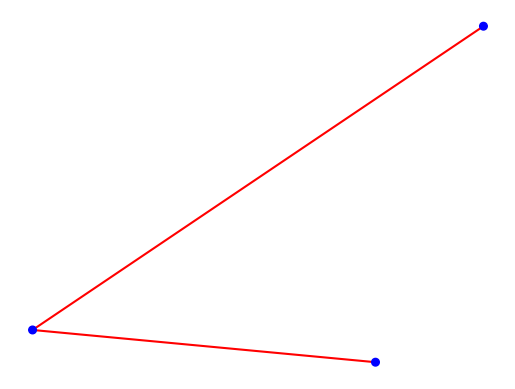

In [8]:
pp.plot(n, backend='matplotlib');

We can also pass a specific layout to the plot function of the network. This will disable the interactive layout, fixing the node positions to the precalculated layout:

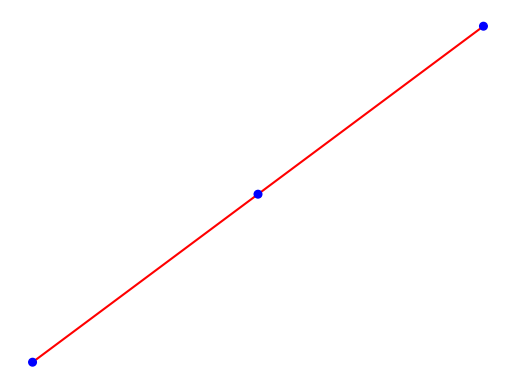

In [9]:
layout = {'a':[0,0],'b':[1,1],"c":[2,2]}
pp.plot(n, backend='matplotlib',layout=layout);

While it is convenient to interactively plot networks in a jupyter network, we often want to generate stand-alone visualisations that we can share or embed in other website. The plot function can be used to generate a stand-alone HTML visualisation of the network that can be opened in any browser and shared on the Web.

In [10]:
pp.plot(n, filename='test_plot.html');